# Tugas Praktikum - K-Means & DBSCAN

**Nama:** Radit Firansah  
**NIM:** 244107020196

## 1. Tugas K-Means (Mall Customers)

Fitur yang tepat: **Annual Income (k$)** dan **Spending Score (1-100)** — keduanya menggambarkan perilaku belanja pelanggan.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

%matplotlib inline

df = pd.read_csv('../data/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


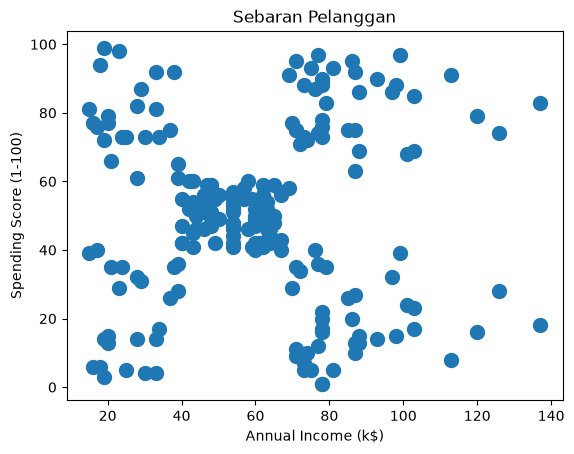

In [2]:
# Seleksi fitur: Annual Income & Spending Score
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s=100)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Sebaran Pelanggan')
plt.show()

### Menentukan k terbaik dengan Metode Elbow

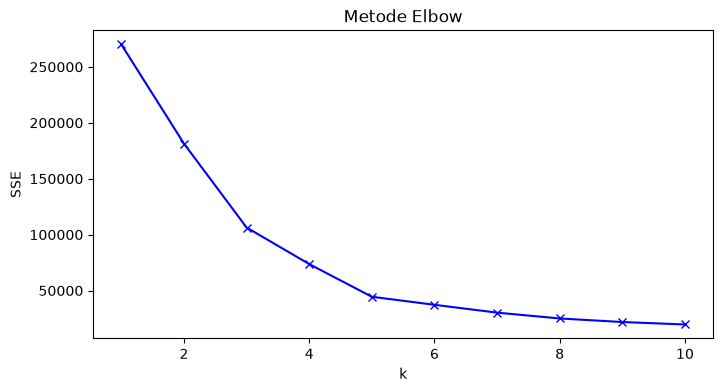

k=1; SSE=269981.280
k=2; SSE=181363.596
k=3; SSE=106348.373
k=4; SSE=73679.789
k=5; SSE=44448.455
k=6; SSE=37265.865
k=7; SSE=30259.657
k=8; SSE=25050.832
k=9; SSE=21862.093
k=10; SSE=19657.784


In [3]:
sse = []
K = range(1, 11)
for k in K:
    km = KMeans(n_clusters=k, n_init=10, random_state=0)
    km.fit(X)
    sse.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, sse, 'bx-')
plt.xlabel('k')
plt.ylabel('SSE')
plt.title('Metode Elbow')
plt.show()

for idx, val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={val:.3f}')

### Model K-Means dengan k terbaik

Elbow terlihat di **k=5**, sehingga kita gunakan k=5.

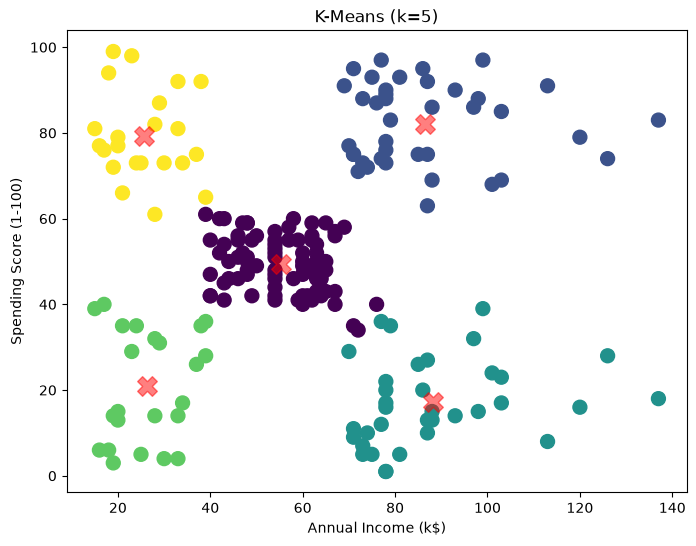

SSE: 44448.45544793371


In [4]:
cl_kmeans = KMeans(n_clusters=5, n_init=10, random_state=0)
y_kmeans = cl_kmeans.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s=100, c=y_kmeans, cmap='viridis')
centers = cl_kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5, marker='X')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means (k=5)')
plt.show()

print(f'SSE: {cl_kmeans.inertia_}')

## 2. Tugas DBSCAN (make_moons)

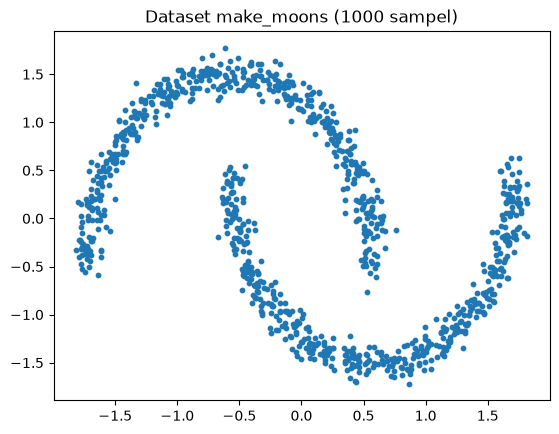

In [5]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn import metrics

X_moons, y_moons = make_moons(n_samples=1000, noise=0.05, random_state=0)
X_moons = StandardScaler().fit_transform(X_moons)

plt.scatter(X_moons[:, 0], X_moons[:, 1], s=10)
plt.title('Dataset make_moons (1000 sampel)')
plt.show()

### DBSCAN eps=0.2, min_samples=5

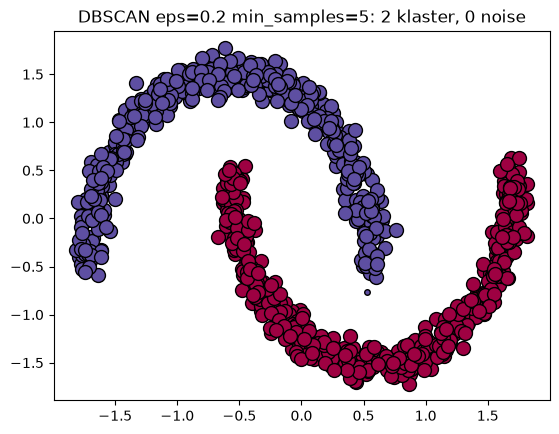

eps: 0.2
min_samples: 5
clusters: 2
noise: 0
homogeneity: 1.0
completeness: 1.0
v_measure: 1.0
ari: 1.0
ami: 1.0
silhouette: 0.3915969903000845


In [6]:
def run_dbscan(X, eps, min_samples, labels_true=None, plot=True):
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    if plot:
        core_mask = np.zeros_like(labels, dtype=bool)
        core_mask[db.core_sample_indices_] = True
        unique_labels = set(labels)
        colors = [plt.cm.Spectral(e) for e in np.linspace(0, 1, len(unique_labels))]
        for k, col in zip(unique_labels, colors):
            if k == -1:
                col = [0, 0, 0, 1]
            m = labels == k
            xy = X[m & core_mask]
            plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
                     markeredgecolor='k', markersize=10)
            xy = X[m & ~core_mask]
            plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
                     markeredgecolor='k', markersize=4)
        plt.title(f'DBSCAN eps={eps} min_samples={min_samples}: {n_clusters} klaster, {n_noise} noise')
        plt.show()

    res = {'eps': eps, 'min_samples': min_samples, 'clusters': n_clusters, 'noise': n_noise}
    if labels_true is not None and n_clusters > 1:
        res.update({
            'homogeneity': metrics.homogeneity_score(labels_true, labels),
            'completeness': metrics.completeness_score(labels_true, labels),
            'v_measure': metrics.v_measure_score(labels_true, labels),
            'ari': metrics.adjusted_rand_score(labels_true, labels),
            'ami': metrics.adjusted_mutual_info_score(labels_true, labels),
            'silhouette': metrics.silhouette_score(X, labels),
        })
    return res, labels

res, labels = run_dbscan(X_moons, 0.2, 5, y_moons)
for k, v in res.items():
    print(f'{k}: {v}')

### Eksperimen Parameter

Variasi `eps = 0.05, 0.1, 0.3, 0.5` dan `min_samples = 3, 10, 20`.

In [7]:
hasil = []
for eps in [0.05, 0.1, 0.2, 0.3, 0.5]:
    for ms in [3, 10, 20]:
        r, _ = run_dbscan(X_moons, eps, ms, y_moons, plot=False)
        hasil.append(r)

hasil_df = pd.DataFrame(hasil)
cols = ['eps', 'min_samples', 'clusters', 'noise', 'homogeneity', 'completeness',
        'v_measure', 'ari', 'ami', 'silhouette']
hasil_df = hasil_df[[c for c in cols if c in hasil_df.columns]]
hasil_df

,eps,min_samples,clusters,noise,homogeneity,completeness,v_measure,ari,ami,silhouette
0,0.05,3,67,197,0.803825,0.154915,0.259767,0.032984,0.246428,0.077967
1,0.05,10,0,1000,NaN,NaN,NaN,NaN,NaN,NaN
2,0.05,20,0,1000,NaN,NaN,NaN,NaN,NaN,NaN
3,0.10,3,3,18,0.983471,0.708395,0.823571,0.854285,0.823246,0.137887
4,0.10,10,9,63,0.938949,0.358282,0.518656,0.435052,0.516899,0.184140
5,0.10,20,6,844,0.157108,0.153385,0.155224,0.010402,0.151519,-0.409118
6,0.20,3,2,0,1.000000,1.000000,1.000000,1.000000,1.000000,0.391597
7,0.20,10,2,0,1.000000,1.000000,1.000000,1.000000,1.000000,0.391597
8,0.20,20,2,5,0.995145,0.956490,0.975435,0.990018,0.975397,0.183099
9,0.30,3,2,0,1.000000,1.000000,1.000000,1.000000,1.000000,0.391597
